In [1]:
import sys
sys.path.append("../../../")

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

from scipy.stats import invgamma
from scipy.stats import multivariate_normal, truncnorm
from scipy.special import log_ndtr

from LRM.plotting import set_plot_style
from LRM.CMP import CMP, SmoothedEmpiricalDensity
from LRM.minimax_tilting_sampler import TruncatedMVN


set_plot_style()

SAVE=False


#SKIP TO PLOTTING if you don't want to re-run stuff.

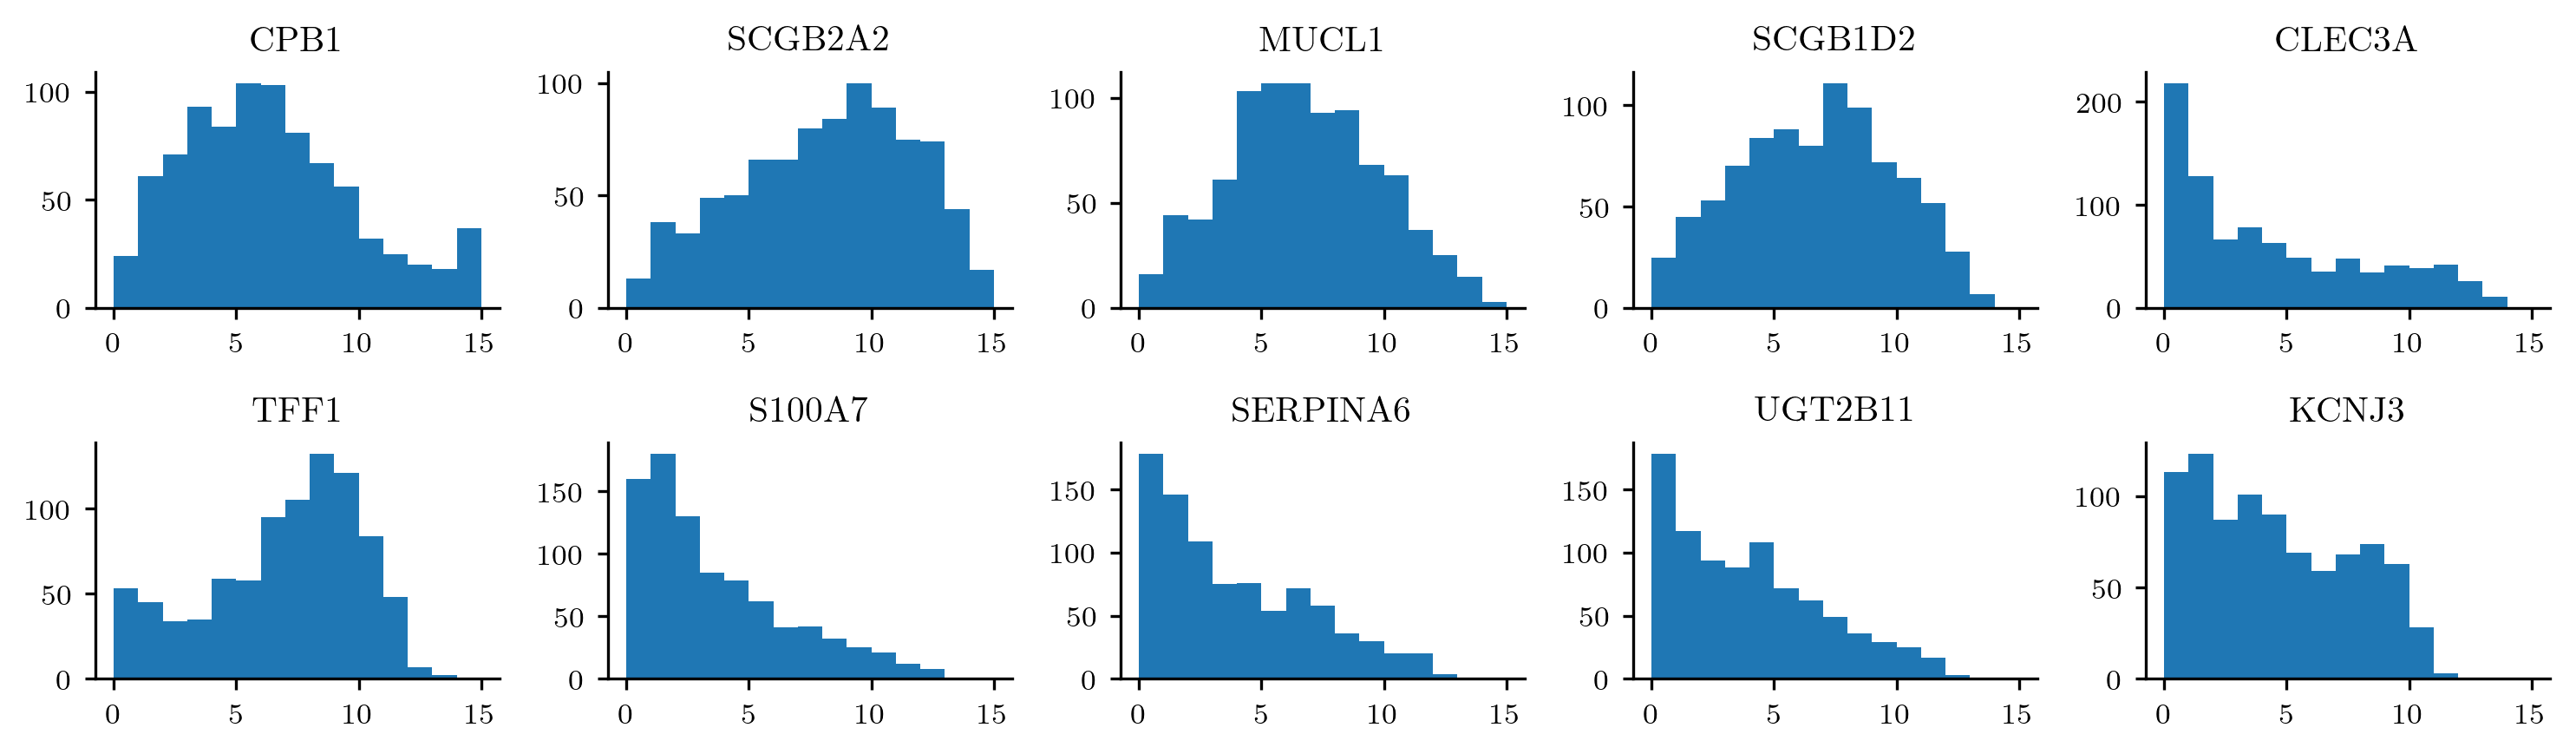

In [2]:
labels = [["CPB1", "SCGB2A2", "MUCL1", "SCGB1D2", "CLEC3A"],["TFF1", "S100A7", "SERPINA6", "UGT2B11", "KCNJ3"]]

def plot_data(samples):
    assert len(samples.shape) == 2 and samples.shape[1] == 10
    fig, axs = plt.subplots(2, 5, figsize=(10,3))

    count = 0
    for i in range(2):
        for j in range(5):
            axs[i, j].hist(samples[:, count], bins=np.arange(16))
            axs[i, j].set_title(labels[i][j])
            count+=1
    
    fig.tight_layout()

raw_data = np.load("../../../data/brca_10.npy").astype(np.int64)
plot_data(raw_data)

## Fitting $\beta$

In [3]:
#Fitting the empirical (and alpha)
alpha = 0.1
empirical = SmoothedEmpiricalDensity(alpha=alpha)
empirical.fit(raw_data)

#Setup for M(x)
d = raw_data.shape[1]
j_bound = 2
model = CMP(d=d, empirical=empirical, j_vals=list(range(-j_bound, j_bound + 1)), circular=True)

#Fitting beta with normal prior (coverage)
mu_prior = np.zeros((model.param_size, 1))
Sigma_prior = np.eye(model.param_size)

beta_star, cov, _ = model.fit_coverage(data=raw_data, prior_mean=mu_prior, prior_cov=Sigma_prior, B=50, beta_low=0.1, beta_high=3., verbose=True)

[scipy] beta*: 1.20836, coverage: 0.9600 (target 0.9500); fun=0.0001, success=True


In [4]:
#Getting posterior (MVN)
posterior = model.posterior(data=raw_data, beta=beta_star, mu_prior=mu_prior, Sigma_prior=Sigma_prior)

# constraints
lb = np.ones_like(posterior.mean) * - np.inf
ub = np.ones_like(posterior.mean) * np.inf

lb[10:] = 0.0 #ensure positivity; here we have d=10 (first 10 parameters) 

# create truncated normal object
tmvn = TruncatedMVN(posterior.mean, posterior.cov, lb, ub)

In [5]:
theta_gaussian = tmvn.sample(5000).mean(axis=1)

## Posterior

In [6]:
def spike_slab_lrm_gibbs(
    model,
    data,
    beta,
    n_samples,
    burnin=0,
    thin=1,
    ss_idx=None,
    slab_sd=0.01,
    always_active_sd=1.0,
    inclusion_a=1.0,
    inclusion_b=1.0,
    fixed_inclusion_prob=None,
    lb=None,
    ub=None,
    seed=None,
):
    """
    Gibbs sampler for LRM-Bayes with an exact point-mass spike at zero.

    Selectable latent coefficients have Gaussian slab prior
    N(0, slab_sd^2). Always-active coefficients use
    N(0, always_active_sd^2).
    while the effective model parameters are theta = gamma * b. Parameters
    outside ss_idx are always active. Therefore theta[j] is exactly zero
    whenever gamma[j] == 0.

    Uses the same scaling convention as model.posterior(), namely:
        precision = 2 * beta * Lambda + prior_precision

    not:
        precision = 2 * beta * n * Lambda + prior_precision

    Args:
        model: fitted model object with compute_matrices(data).
        data: array of observations.
        beta: learning rate.
        n_samples: number of kept posterior samples.
        burnin: number of burn-in iterations.
        thin: thinning interval.
        ss_idx: indices eligible for exact-zero selection.
        slab_sd: standard deviation of selectable slab coefficients.
        always_active_sd: prior standard deviation outside ss_idx.
        inclusion_a, inclusion_b: beta-prior parameters for inclusion_prob.
        fixed_inclusion_prob: if supplied, keep the prior probability that
            an interaction is active fixed at this value instead of learning
            a shared probability from gamma. This avoids global sparsity
            feedback when only mild selection is desired.
        lb, ub: optional lower/upper bounds for latent slab coefficients.
        seed: random seed.

    Returns:
        dict with effective theta samples, latent slab coefficients, gamma,
        and inclusion_prob.
    """

    rng = np.random.default_rng(seed)

    Lambda, nu, _ = model.compute_matrices(data=data)

    p = model.param_size

    if ss_idx is None:
        ss_idx = np.arange(p)
    else:
        ss_idx = np.asarray(ss_idx, dtype=int)

    if ss_idx.ndim != 1 or len(np.unique(ss_idx)) != len(ss_idx):
        raise ValueError("ss_idx must contain unique one-dimensional indices.")
    if np.any((ss_idx < 0) | (ss_idx >= p)):
        raise ValueError("ss_idx contains an index outside the parameter vector.")
    if slab_sd <= 0.0 or always_active_sd <= 0.0:
        raise ValueError("Prior standard deviations must be positive.")
    if inclusion_a <= 0.0 or inclusion_b <= 0.0:
        raise ValueError("Beta-prior parameters must be positive.")
    if fixed_inclusion_prob is not None and not 0.0 < fixed_inclusion_prob < 1.0:
        raise ValueError("fixed_inclusion_prob must lie strictly between 0 and 1.")

    if (lb is None) != (ub is None):
        raise ValueError("lb and ub must either both be supplied or both be None.")
    if lb is not None:
        lb = np.asarray(lb, dtype=float).reshape(-1)
        ub = np.asarray(ub, dtype=float).reshape(-1)
        if lb.shape != (p,) or ub.shape != (p,):
            raise ValueError("lb and ub must each have shape (model.param_size,).")

    # Parameters outside ss_idx are always active. The selectable parameters
    # are always included; selectable parameters start from a draw from the
    # prior inclusion probability.
    initial_inclusion_prob = (
        fixed_inclusion_prob
        if fixed_inclusion_prob is not None
        else inclusion_a / (inclusion_a + inclusion_b)
    )
    gamma = np.ones(p, dtype=np.int8)
    gamma[ss_idx] = rng.binomial(1, initial_inclusion_prob, size=len(ss_idx))
    slab_coefficients = np.zeros(p)
    theta = gamma * slab_coefficients
    inclusion_prob = initial_inclusion_prob
    prior_precision = np.full(p, 1.0 / always_active_sd**2)
    prior_precision[ss_idx] = 1.0 / slab_sd**2

    total_iters = burnin + n_samples * thin

    theta_samples = []
    slab_coefficient_samples = []
    gamma_samples = []
    inclusion_prob_samples = []

    for it in tqdm(range(total_iters)):

        # ----- latent slab coefficients | gamma, data -----

        # With theta = D_gamma b, the quadratic loss uses
        # D_gamma Lambda D_gamma and D_gamma nu.
        masked_Lambda = Lambda * gamma[:, None] * gamma[None, :]
        Precision = 2.0 * beta * masked_Lambda + np.diag(prior_precision)
        Sigma = np.linalg.inv(Precision)
        mu = Sigma @ (2.0 * beta * gamma * nu.reshape(-1))

        if lb is None and ub is None:
            slab_coefficients = rng.multivariate_normal(mean=mu, cov=Sigma)
        else:
            tmvn = TruncatedMVN(mu, Sigma, lb, ub)
            slab_coefficients = tmvn.sample(1)

        # TruncatedMVN.sample(1) returns shape (p, 1); use (p,) consistently.
        slab_coefficients = np.asarray(slab_coefficients).reshape(-1)
        if lb is not None:
            tolerance = 1e-12
            if np.any(slab_coefficients < lb - tolerance) or np.any(slab_coefficients > ub + tolerance):
                raise RuntimeError("TruncatedMVN returned a draw outside the requested bounds.")

        # ----- gamma_j | theta_-j, inclusion_prob, data -----

        safe_inclusion_prob = np.clip(inclusion_prob, 1e-12, 1.0 - 1e-12)
        log_prior_odds = np.log(safe_inclusion_prob) - np.log1p(-safe_inclusion_prob)
        theta = gamma * slab_coefficients
        for j in rng.permutation(ss_idx):
            # Remove j, analytically integrate its slab coefficient over its
            # allowed interval, and compare the resulting marginal density
            # with the point mass at zero.
            theta[j] = 0.0
            slab_variance = slab_sd**2
            conditional_precision = 2.0 * beta * Lambda[j, j] + 1.0 / slab_variance
            conditional_linear = 2.0 * beta * (nu[j, 0] - Lambda[j] @ theta)
            conditional_variance = 1.0 / conditional_precision
            conditional_sd = np.sqrt(conditional_variance)
            conditional_mean = conditional_linear * conditional_variance

            lower_prior = lb[j] / slab_sd if lb is not None else -np.inf
            upper_prior = ub[j] / slab_sd if ub is not None else np.inf
            lower_post = (
                (lb[j] - conditional_mean) / conditional_sd
                if lb is not None else -np.inf
            )
            upper_post = (
                (ub[j] - conditional_mean) / conditional_sd
                if ub is not None else np.inf
            )

            def log_interval_probability(lower, upper):
                log_upper = log_ndtr(upper)
                log_lower = log_ndtr(lower)
                if np.isneginf(log_lower):
                    return log_upper
                return log_upper + np.log1p(-np.exp(log_lower - log_upper))

            log_prior_interval = log_interval_probability(lower_prior, upper_prior)
            log_posterior_interval = log_interval_probability(lower_post, upper_post)
            log_bayes_factor = (
                -np.log(slab_sd)
                - 0.5 * np.log(conditional_precision)
                + 0.5 * conditional_linear**2 / conditional_precision
                + log_posterior_interval
                - log_prior_interval
            )
            log_odds = log_prior_odds + log_bayes_factor
            if log_odds >= 0.0:
                inclusion_probability = 1.0 / (1.0 + np.exp(-log_odds))
            else:
                exp_log_odds = np.exp(log_odds)
                inclusion_probability = exp_log_odds / (1.0 + exp_log_odds)
            gamma[j] = rng.binomial(1, inclusion_probability)

            if gamma[j] == 1:
                slab_coefficients[j] = truncnorm.rvs(
                    a=lower_post,
                    b=upper_post,
                    loc=conditional_mean,
                    scale=conditional_sd,
                    random_state=rng,
                )
                theta[j] = slab_coefficients[j]
            else:
                slab_coefficients[j] = 0.0
                theta[j] = 0.0

        # ----- inclusion_prob | gamma -----

        if fixed_inclusion_prob is None:
            included = gamma[ss_idx].sum()
            inclusion_prob = rng.beta(
                inclusion_a + included,
                inclusion_b + len(ss_idx) - included,
            )
        else:
            inclusion_prob = fixed_inclusion_prob

        # ----- store -----

        if it >= burnin and (it - burnin) % thin == 0:
            theta_samples.append(theta.copy())
            slab_coefficient_samples.append(slab_coefficients.copy())
            gamma_samples.append(gamma.copy())
            inclusion_prob_samples.append(inclusion_prob)

    return {
        "theta": np.asarray(theta_samples),
        "slab_coefficients": np.asarray(slab_coefficient_samples),
        "gamma": np.asarray(gamma_samples),
        "inclusion_prob": np.asarray(inclusion_prob_samples),
    }

In [7]:
# --------------------------------------------------
# Run spike-and-slab Gibbs sampler
# --------------------------------------------------

beta = beta_star

lb = np.ones(model.param_size) * -np.inf
ub = np.ones(model.param_size) * np.inf

# CMP parameter layout for d=10:
#   0:10   main effects (unconstrained)
#   10:55  pairwise interactions (nonnegative)
#   55:65  dispersion parameters (nonnegative)
lb[model.d:] = 0.0

# Exact-zero selection only for the 45 pairwise interactions.
# Main effects and dispersion parameters remain active in every draw.
ss_idx = np.arange(model.d, model.param_size - model.d)
# ss_idx = None
slab_sd = 0.005
fixed_inclusion_prob = 0.85

# LRM_spike_slab_samples = spike_slab_lrm_gibbs(
#     model=model,
#     data=raw_data,
#     beta=beta,
#     n_samples=5_000,
#     burnin=1_000,
#     thin=1,
#     ss_idx=ss_idx,
#     # Mild exact sparsity: interactions remain active a priori with high
#     # probability, while the slab matches their observed small scale.
#     slab_sd=slab_sd,
#     always_active_sd=1.0,
#     inclusion_a=1.0,
#     inclusion_b=1.0,
#     fixed_inclusion_prob=fixed_inclusion_prob,
#     lb=lb,
#     ub=ub,
#     seed=123,
# )

# np.savez(
#     f"outputs/posterior_samples_LRM_spike_slab_calibrated_alpha={alpha}.npz",
#     theta=LRM_spike_slab_samples["theta"],
#     slab_coefficients=LRM_spike_slab_samples["slab_coefficients"],
#     gamma=LRM_spike_slab_samples["gamma"],
#     inclusion_prob=LRM_spike_slab_samples["inclusion_prob"],
# )
#Takes about 5 minutes 30 seconds for 6000 samples

 39%|███▉      | 2354/6000 [01:33<02:26, 24.83it/s]/var/folders/gv/s498ttt962vdwllxhvsv1xs00000gn/T/ipykernel_28756/343589400.py:167: RuntimeWarning: divide by zero encountered in log1p
  return log_upper + np.log1p(-np.exp(log_lower - log_upper))
100%|██████████| 6000/6000 [03:50<00:00, 26.00it/s]


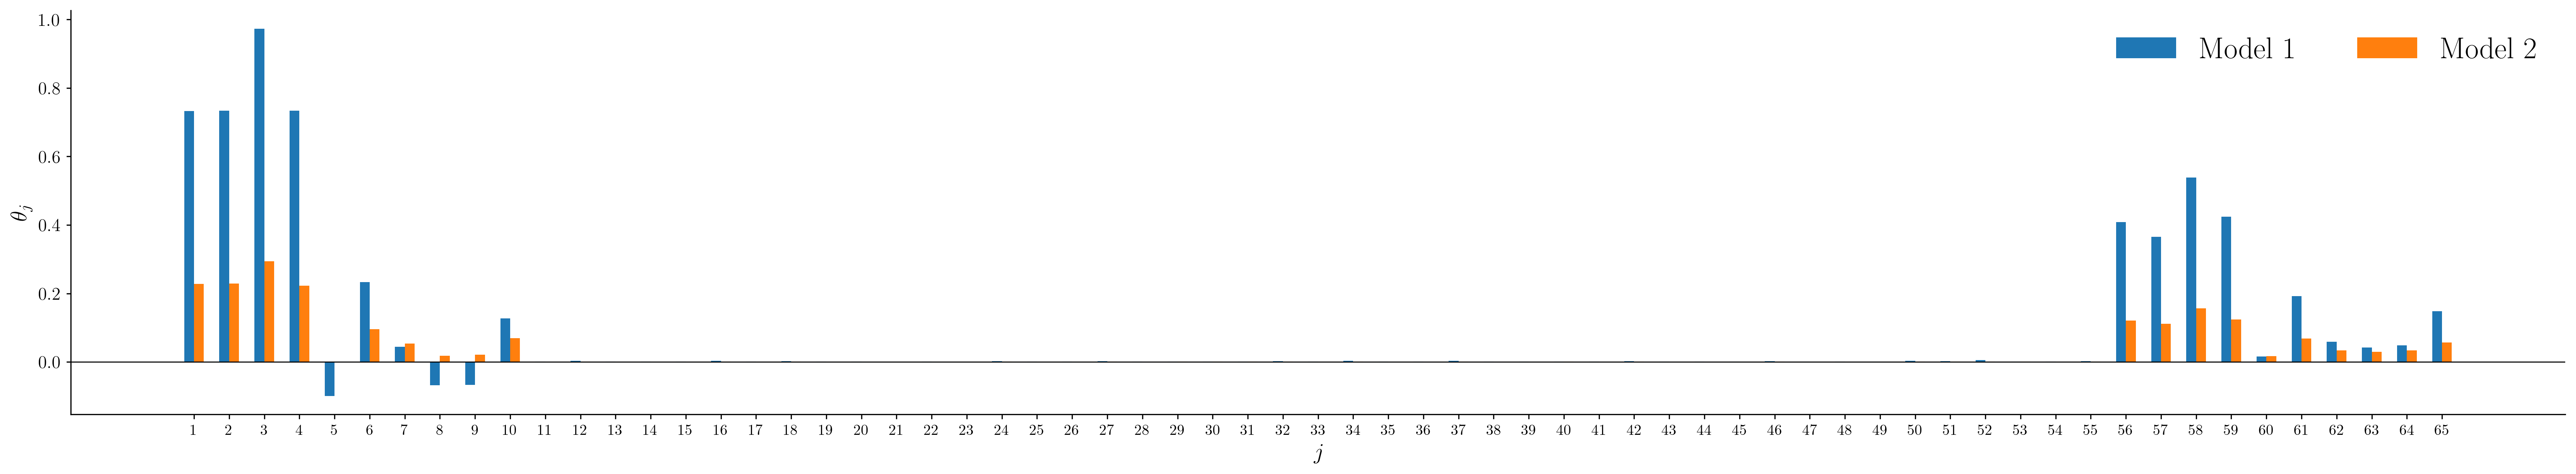

In [ ]:
# Compare parameters from spike-and-slab to parameters from Gaussian

theta_model_1 = theta_gaussian.flatten()
theta_model_2 = np.load(f"outputs/posterior_samples_LRM_spike_slab_calibrated_alpha={alpha}.npz")['theta'].mean(axis=0).flatten()

p = len(theta_model_1)
x = np.arange(1, p + 1)

bar_width = 0.28

fig, ax = plt.subplots(figsize=(24, 4.5))

ax.bar(
    x - bar_width / 2,
    theta_model_1,
    width=bar_width,
    label="Model 1",
)

ax.bar(
    x + bar_width / 2,
    theta_model_2,
    width=bar_width,
    label="Model 2",
)

ax.axhline(0, color="black", linewidth=0.7)

ax.set_xlabel(r"$j$", fontsize=15)
ax.set_ylabel(r"$\theta_j$", fontsize=15)

ax.set_xticks(x)
ax.set_xticklabels([str(j) for j in x], fontsize=10)

ax.tick_params(axis="y", labelsize=12)
ax.legend(frameon=False, fontsize=20, ncol=2)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## Simple sparsity analysis

In [9]:
# Simple comparison of sparsity in the interaction parameters.
LRM_spike_slab_samples = np.load(
    f"outputs/posterior_samples_LRM_spike_slab_calibrated_alpha={alpha}.npz"
)
interaction_idx = np.arange(model.d, model.param_size - model.d)
interaction_pairs = list(zip(*np.triu_indices(model.d, k=1)))
gene_names = labels[0] + labels[1]
interaction_names = [f"{gene_names[i]}--{gene_names[j]}" for i, j in interaction_pairs]

gaussian_mean = theta_gaussian.flatten()[interaction_idx]
spike_slab_draws = LRM_spike_slab_samples["theta"][:, interaction_idx]
spike_slab_mean = spike_slab_draws.mean(axis=0)

# Average proportion of interactions set exactly to zero in each posterior draw.
zero_fraction = np.mean(spike_slab_draws == 0.0)
magnitude_reduction = 1.0 - (
    np.abs(spike_slab_mean) / np.maximum(np.abs(gaussian_mean), 1e-12)
)
median_reduction = np.median(magnitude_reduction)

# For each interaction, the proportion of posterior draws in which it is zero.
zero_frequency = np.mean(spike_slab_draws == 0.0, axis=0)
most_excluded = np.argsort(zero_frequency)[::-1][:5]

print(f"1. Exact-zero fraction: {zero_fraction:.1%} for spike-and-slab versus 0% for the continuous Gaussian posterior.")
print("   This is the average fraction of interaction coefficients set exactly to zero in a posterior draw.")
print("   It shows that the spike-and-slab posterior introduces genuine sparsity.")

print(f"\n2. Median magnitude reduction: {median_reduction:.1%}.")
print("   For a typical interaction, this is the reduction in the absolute posterior mean relative to the Gaussian model.")
print("   The posterior mean is usually not exactly zero because it averages zero and nonzero draws.")

print("\n3. Interactions most frequently set to zero:")
for k in most_excluded:
    print(f"   {interaction_names[k]:20s}: zero in {zero_frequency[k]:.1%} of draws")
print("   Higher zero frequency means weaker evidence that the interaction is needed.")


1. Exact-zero fraction: 42.7% for spike-and-slab versus 0% for the continuous Gaussian posterior.
   This is the average fraction of interaction coefficients set exactly to zero in a posterior draw.
   It shows that the spike-and-slab posterior introduces genuine sparsity.

2. Median magnitude reduction: 47.8%.
   For a typical interaction, this is the reduction in the absolute posterior mean relative to the Gaussian model.
   The posterior mean is usually not exactly zero because it averages zero and nonzero draws.

3. Interactions most frequently set to zero:
   SCGB2A2--SCGB1D2    : zero in 76.4% of draws
   SCGB2A2--TFF1       : zero in 62.8% of draws
   SCGB1D2--TFF1       : zero in 61.1% of draws
   SCGB2A2--UGT2B11    : zero in 60.0% of draws
   SCGB2A2--MUCL1      : zero in 57.6% of draws
   Higher zero frequency means weaker evidence that the interaction is needed.


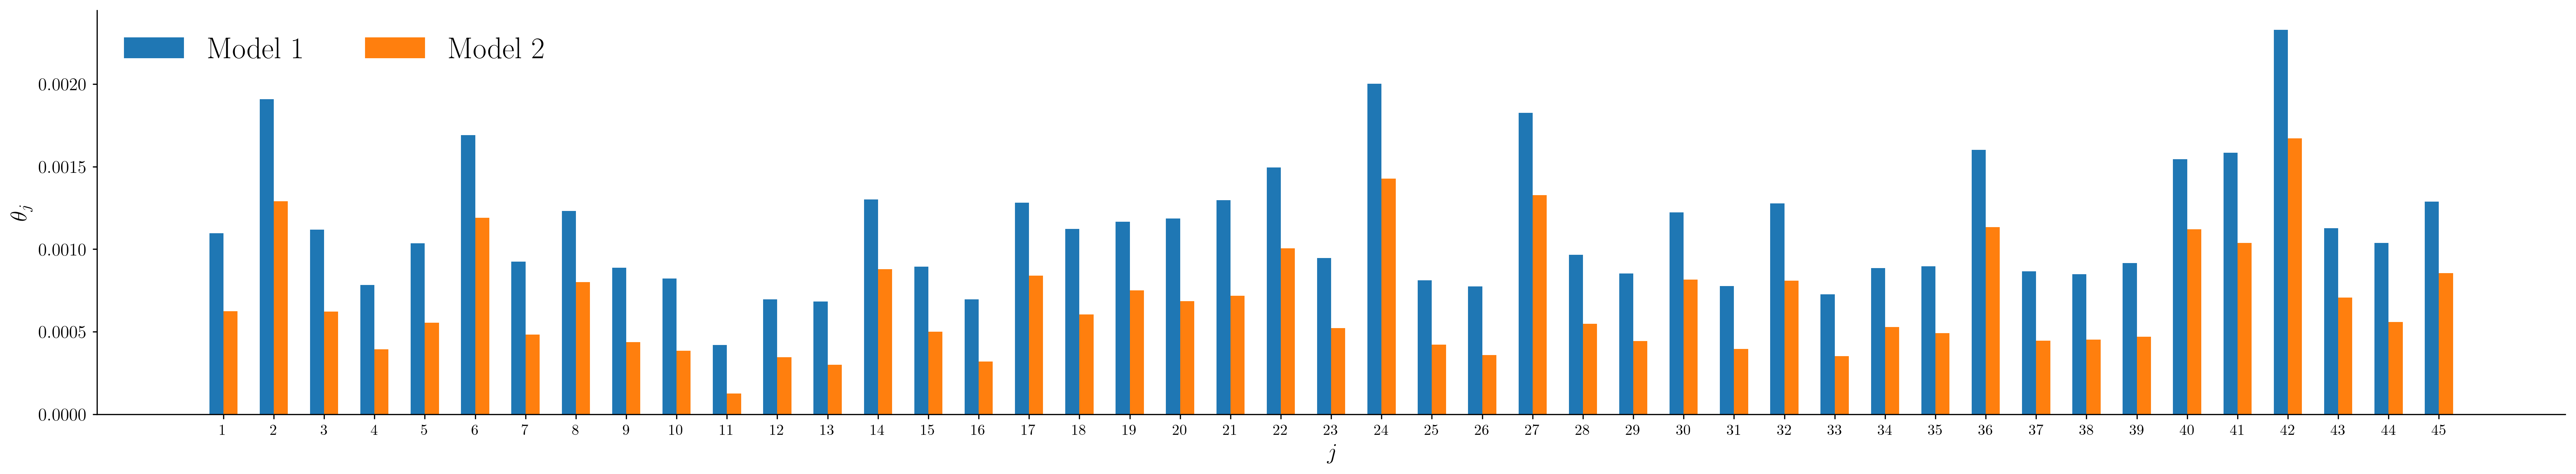

In [ ]:
# Compare parameters from spike-and-slab to parameters from Gaussian

theta_model_1 = theta_gaussian.flatten()[10:-10]
theta_model_2 = np.load(f"outputs/posterior_samples_LRM_spike_slab_calibrated_alpha={alpha}.npz")['theta'].mean(axis=0).flatten()[10:-10]

p = len(theta_model_1)
x = np.arange(1, p + 1)

bar_width = 0.28

fig, ax = plt.subplots(figsize=(24, 4.5))

ax.bar(
    x - bar_width / 2,
    theta_model_1,
    width=bar_width,
    label="Model 1",
)

ax.bar(
    x + bar_width / 2,
    theta_model_2,
    width=bar_width,
    label="Model 2",
)

ax.axhline(0, color="black", linewidth=0.7)

ax.set_xlabel(r"$j$", fontsize=15)
ax.set_ylabel(r"$\theta_j$", fontsize=15)

ax.set_xticks(x)
ax.set_xticklabels([str(j) for j in x], fontsize=10)

ax.tick_params(axis="y", labelsize=12)
ax.legend(frameon=False, fontsize=20, ncol=2)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## Posterior Predictive

In [10]:
def metropolis_hastings(log_prob, x0, n_samples, proposal_width=1, burn_in=1000, N_MAX=30):
    d = len(x0)
    samples = []
    x = x0.copy()
    log_p_x = log_prob(x)

    for step in tqdm(range(n_samples + burn_in)):
        # Propose a new sample by modifying one random coordinate
        proposal = x.copy()
        idx = np.random.randint(d)
        move = np.random.choice([-proposal_width, proposal_width])
        proposal[idx] = np.clip(proposal[idx] + move, 0, N_MAX)

        log_p_prop = log_prob(proposal)
        accept_ratio = np.exp(log_p_prop - log_p_x)

        if np.random.rand() < accept_ratio:
            x = proposal
            log_p_x = log_p_prop

        if step >= burn_in:
            samples.append(x.copy())

    return np.array(samples)

def thin_chain(samples, thinning_interval):
    return samples[::thinning_interval]

In [11]:
def get_posterior_predictive_LRM_spike_slab(
    spike_slab_samples,
    model,
    raw_data,
    num_predictive_samples=None,
    mh_n_samples=10_000,
    mh_burn_in=5_000,
    thinning_interval=10,
    N_MAX=25,
    seed=None,
):
    """
    Posterior predictive samples using theta draws from spike_slab_lrm_gibbs().
    """

    rng = np.random.default_rng(seed)

    theta_samples = spike_slab_samples["theta"]

    if num_predictive_samples is None:
        num_predictive_samples = raw_data.shape[0]

    predictive_data = []

    for _ in tqdm(range(num_predictive_samples)):

        theta_idx = rng.integers(theta_samples.shape[0])
        #params = theta_samples[theta_idx]
        params = np.asarray(theta_samples[theta_idx]).reshape(-1)

        all_model_data = metropolis_hastings(
            lambda x: model.log_prob(x, params=params),
            x0=raw_data[0],
            n_samples=mh_n_samples,
            burn_in=mh_burn_in,
            N_MAX=N_MAX,
        )

        model_data = thin_chain(
            all_model_data,
            thinning_interval=thinning_interval,
        )

        pred_idx = rng.integers(model_data.shape[0])
        predictive_data.append(model_data[pred_idx])

    return np.stack(predictive_data)

In [12]:
# --------------------------------------------------
# Run posterior predictive simulation
# --------------------------------------------------
RUN_PREDICTIVE = False

if RUN_PREDICTIVE:

    LRM_spike_slab_predictive_data = get_posterior_predictive_LRM_spike_slab(
        spike_slab_samples=LRM_spike_slab_samples,
        model=model,
        raw_data=raw_data,
        num_predictive_samples=raw_data.shape[0],
        mh_n_samples=10_000,
        mh_burn_in=5_000,
        thinning_interval=10,
        N_MAX=25,
        seed=123,
    )

    np.savez(
        f"outputs/posterior_pred_samples_LRM_spike_slab_calibrated_alpha={alpha}.npz",
        model_data=LRM_spike_slab_predictive_data,
    )

100%|██████████| 878/878 [10:53<00:00,  1.34it/s]


## Plotting

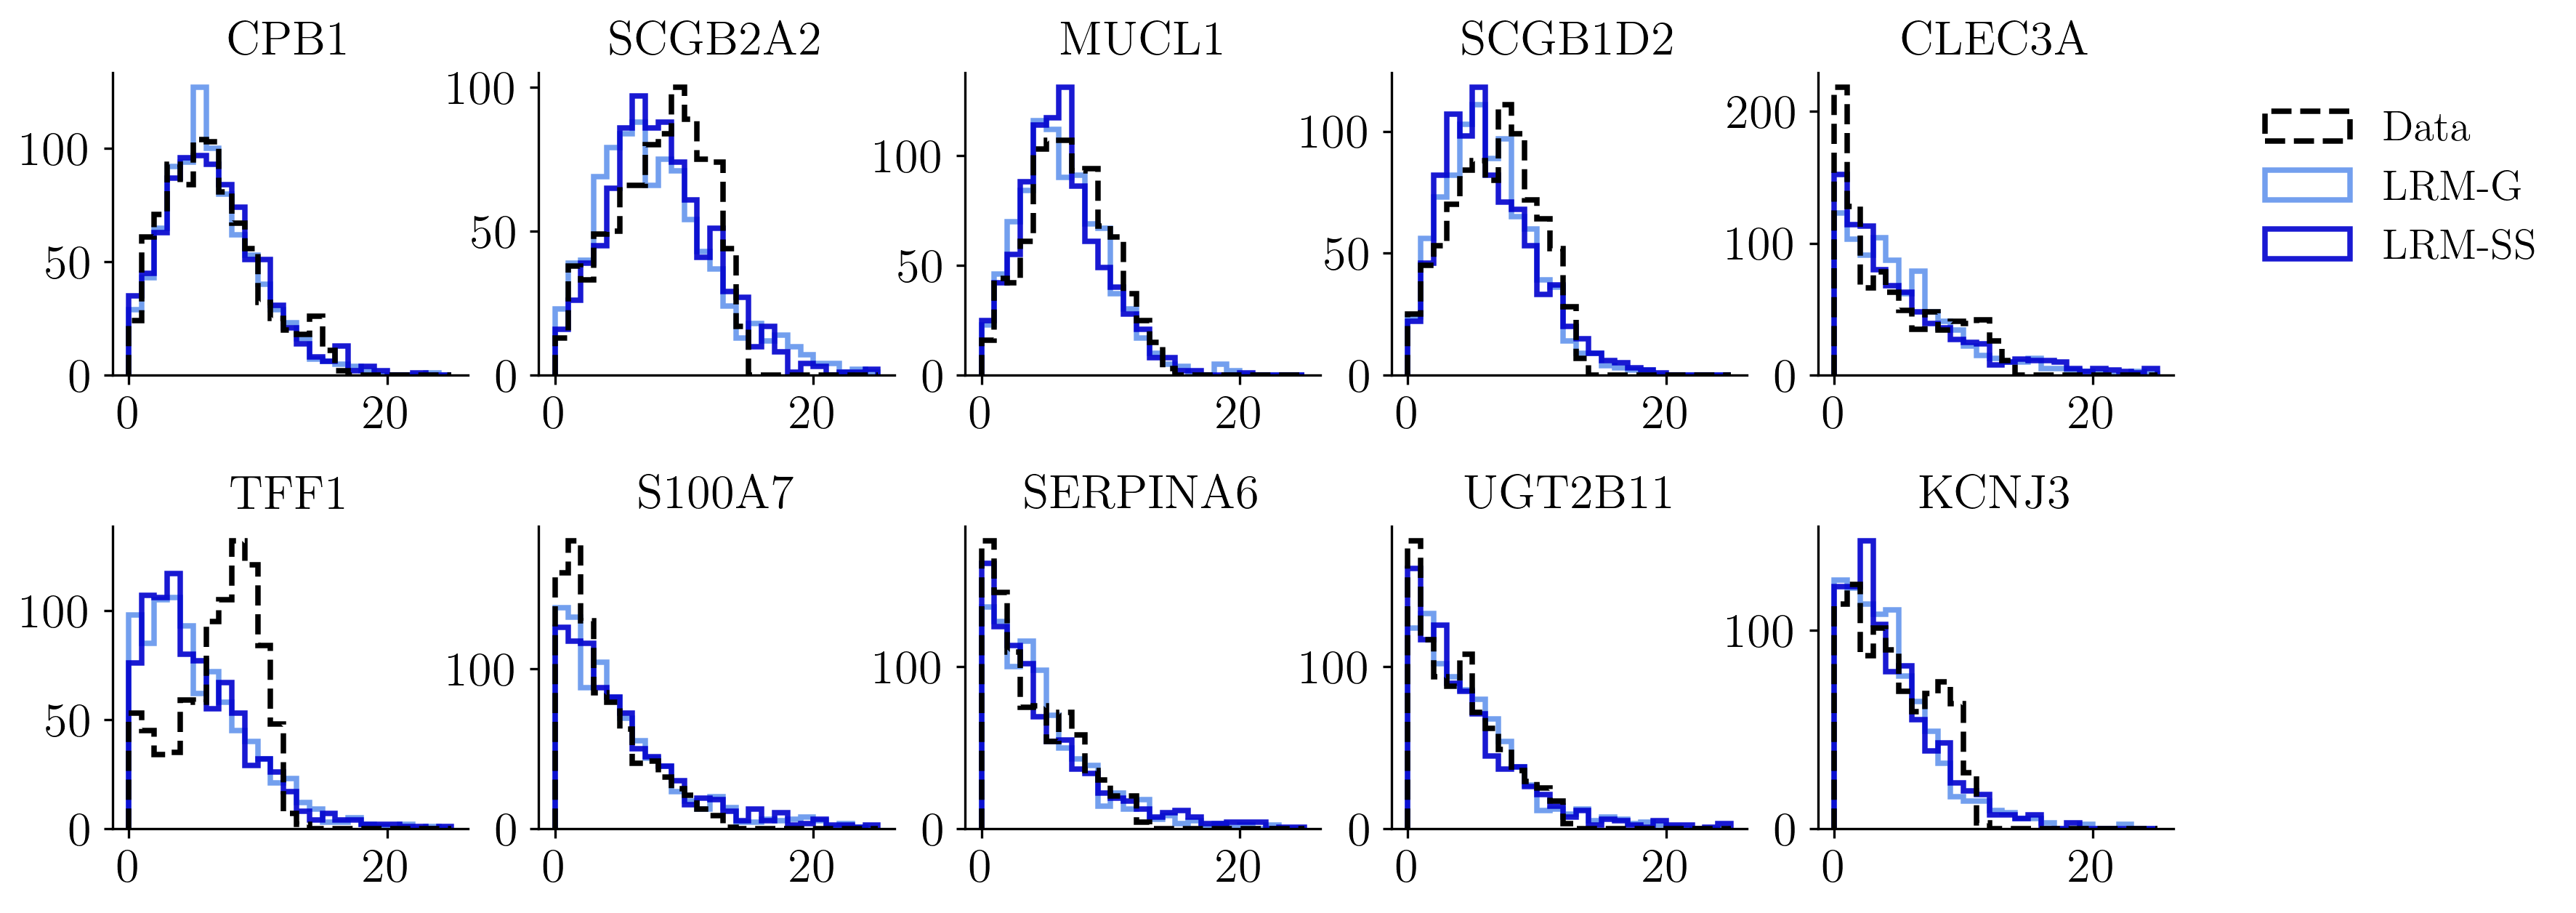

In [15]:
fig, axs = plt.subplots(2, 5, figsize=(12.2,4.5))
labels = [["CPB1", "SCGB2A2", "MUCL1", "SCGB1D2", "CLEC3A"],["TFF1", "S100A7", "SERPINA6", "UGT2B11", "KCNJ3"]]
N_MAX=25
model_data_gaussian_prior = np.load(f"outputs/posterior_pred_samples_LRM_calibrated_alpha={alpha}.npz")["model_data"]
model_data_spike_slab_prior = np.load(f"outputs/posterior_pred_samples_LRM_spike_slab_calibrated_alpha={alpha}.npz")["model_data"]
count = 0
lw = 1.8
for i in range(2):
    for j in range(5):
        axs[i, j].hist(raw_data[:, count], histtype='step', bins=np.arange(N_MAX+1), label="Data",color='black', linestyle='--', linewidth=lw, zorder=3)
        axs[i, j].hist(model_data_gaussian_prior[:, count], histtype='step', bins=np.arange(N_MAX+1), label="LRM-G", color='cornflowerblue', linestyle='-', linewidth=lw, alpha=0.9, zorder=1)
        axs[i, j].hist(model_data_spike_slab_prior[:, count], histtype='step', bins=np.arange(N_MAX+1), label="LRM-SS", color='mediumblue', linestyle='-', linewidth=lw, alpha=0.9, zorder=1)
        axs[i, j].set_title(labels[i][j], fontsize=16)
        count+=1

axs[0,-1].legend(frameon=False, fontsize=14, bbox_to_anchor=(1.15, 1))

for ax in axs.flat:
    ax.tick_params(axis='both', labelsize=16)

fig.subplots_adjust(hspace=0.5)

if SAVE:
    plt.savefig("./results/BRCA-fit-spike-slab-vs-Gaussian.pdf", format='pdf', bbox_inches='tight')